In [1]:
# MSIT 3103 — Environment setup (run this cell once per machine)
# Installs/updates the required packages into the same Python used by this notebook

import sys
print(f"Using Python {sys.version.split()[0]}")

# Install required packages into the current notebook environment
%pip install -qU numpy matplotlib scikit-learn torch torchvision


# Verify versions
import numpy as np, matplotlib, sklearn
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("✅ Setup complete!")


Using Python 3.10.11
Note: you may need to restart the kernel to use updated packages.
numpy       : 2.2.6
matplotlib  : 3.10.8
scikit-learn: 1.7.2
✅ Setup complete!


# Assignment 1: Foundations Reflection - Hot Start

## Discriminative vs. Generative Models
This notebook implements and contrasts two fundamental AI model types on a simple, well‑known dataset. A **logistic regression** classifier acts as our discriminative model, while a **basic generative adversarial network (GAN)** implemented from scratch serves as our generative model. By training these models on the same data, we can observe differences in their training dynamics, performance and behaviour.

## Dataset: MNIST (28×28)



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# Load MNIST (no tensorflow required)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32)        # (70000, 784)
y = mnist.target.astype(int)             # labels 0-9

# Logistic Regression input: scale to [0,1]
X_lr = X / 255.0

# GAN input: scale to [-1, 1]
X_gan = X_lr * 2 - 1


print("X_gan range:", X_gan.min(), X_gan.max())
print("MNIST loaded:", X.shape, y.shape)
print("Classes:", np.unique(y))


X_gan range: -1.0 1.0
MNIST loaded: (70000, 784) (70000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


### Visualising sample digits
Below we plot a handful of digits from the dataset.  This provides anintuition for the data we will feed into both models.  Each image isdisplayed as an 28x28 grid of grayscale pixels.

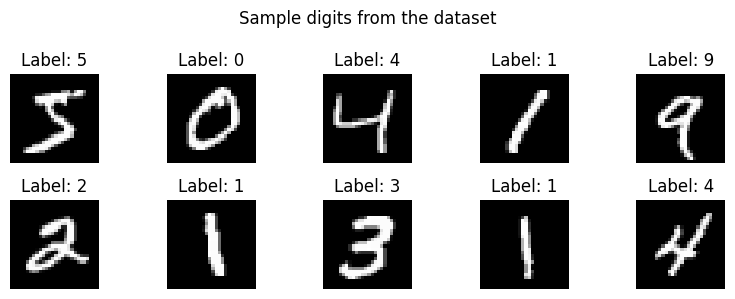

In [3]:
# Plot the first 10 digits
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.suptitle('Sample digits from the dataset')
plt.tight_layout()
plt.show()


## Discriminative Model: Logistic Regression
Logistic regression is a linear classifier that models the probability ofeach class using a softmax function.  It is trained via maximum likelihoodto separate classes based on input features.  Here we train it on atrain/test split of the digits dataset and report standard classificationmetrics.

C=0.1   accuracy=0.9215
C=1.0   accuracy=0.9209
C=10.0  accuracy=0.9181
Logistic regression test accuracy: 0.9209
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.89      1428
           4       0.93      0.92      0.92      1365
           5       0.88      0.87      0.88      1263
           6       0.94      0.95      0.95      1375
           7       0.93      0.95      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



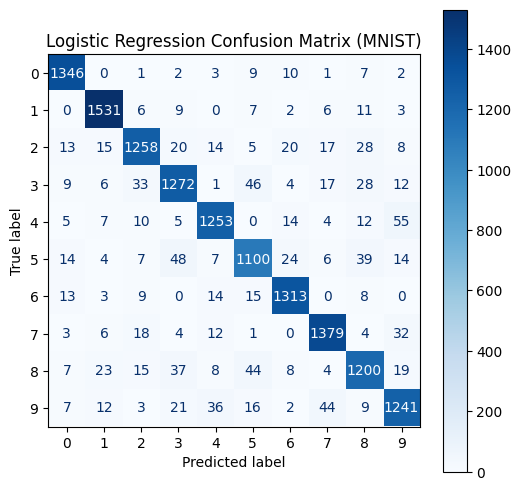

In [4]:
# Split the data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

# Mini hyperparameter tuning
for C in [0.1, 1.0, 10.0]:
    model = LogisticRegression(max_iter=2000, C=C, solver="lbfgs")
    model.fit(X_train_lr, y_train_lr)
    acc = model.score(X_test_lr, y_test_lr)
    print(f"C={C:<4}  accuracy={acc:.4f}")

# Train final model (pick best C from above)
lr_model = LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs")
lr_model.fit(X_train_lr, y_train_lr)

# Evaluate
y_pred_lr = lr_model.predict(X_test_lr)
accuracy = (y_pred_lr == y_test_lr).mean()
print(f"Logistic regression test accuracy: {accuracy:.4f}")

print(classification_report(y_test_lr, y_pred_lr))

cm = confusion_matrix(y_test_lr, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix (MNIST)")
plt.show()


### Observations
Logistic Regression achieved ~92% test accuracy on MNIST after scaling pixel values to [0,1]. Hyperparameter tuning showed the best performance at C=0.1, suggesting stronger regularization improved generalization. The confusion matrix indicates most predictions fall on the diagonal, with errors mainly occurring between visually similar digits such as 4 vs 9, 9 vs 7, and 8 vs 5/3, reflecting the limits of a linear model on handwritten image data.

## Generative Model: Simple GAN implemented
A generative adversarial network consists of two neural networks — a generator $G$ and a discriminator $D$ — that play a minimax game. The generator receives random noise as input and tries to produce outputs that resemble real images; the discriminator learns to distinguish real datafrom generated data. During training, $D$ is optimised to maximize the probability of correctly classifying real versus generated images, while $G$ is optimized to fool $D$. In this notebook we implement a very small GAN from scratch using NumPy without the aid of deep‑learning frameworks. Due to the simplicity of the architecture and the low‑resolution dataset, the generated images do not achieve human‑level quality, but the exercise illustrates training dynamics and highlights challenge ssuch as instability and slow convergence.

Using device: cpu
Epoch 2/10, Step 500, Loss_D=0.9371, Loss_G=1.4423


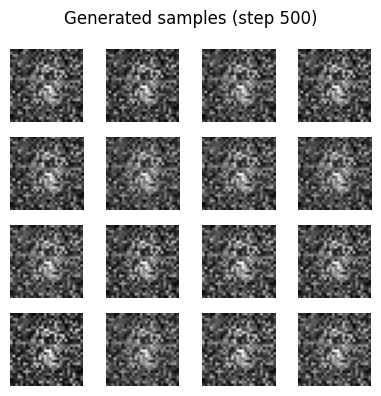

Epoch 3/10, Step 1000, Loss_D=0.8069, Loss_G=2.2549


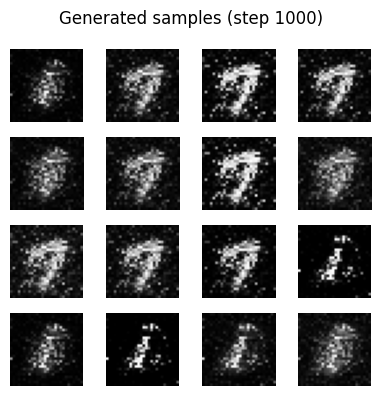

Epoch 4/10, Step 1500, Loss_D=0.8920, Loss_G=1.4047


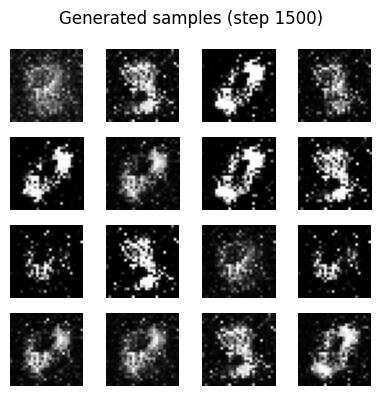

Epoch 5/10, Step 2000, Loss_D=0.9917, Loss_G=2.1417


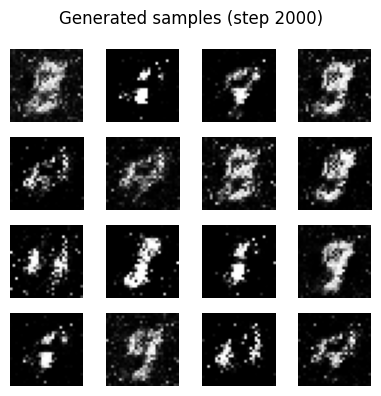

Epoch 6/10, Step 2500, Loss_D=1.1470, Loss_G=3.1254


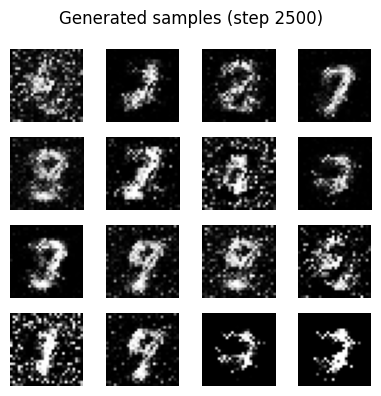

Epoch 7/10, Step 3000, Loss_D=0.8827, Loss_G=1.5127


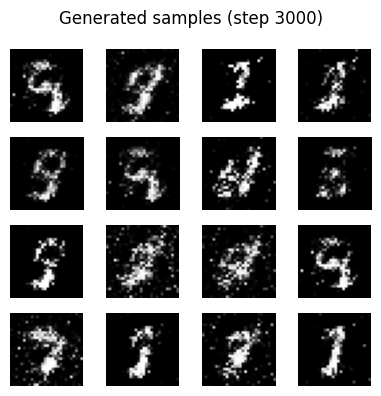

Epoch 8/10, Step 3500, Loss_D=0.7961, Loss_G=1.5854


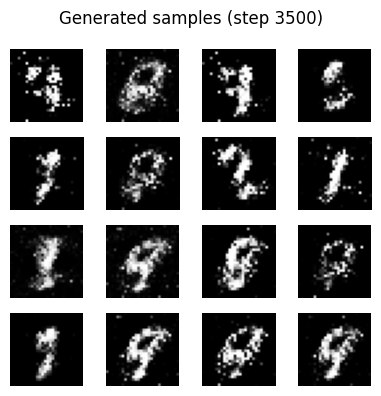

Epoch 9/10, Step 4000, Loss_D=0.9631, Loss_G=1.3733


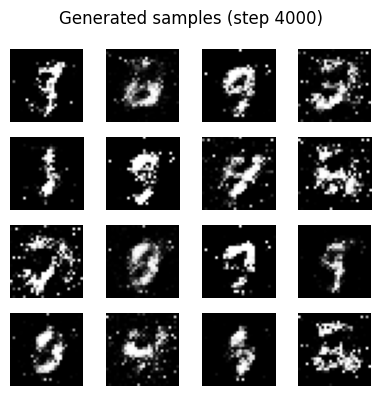

Epoch 10/10, Step 4500, Loss_D=0.8923, Loss_G=1.9002


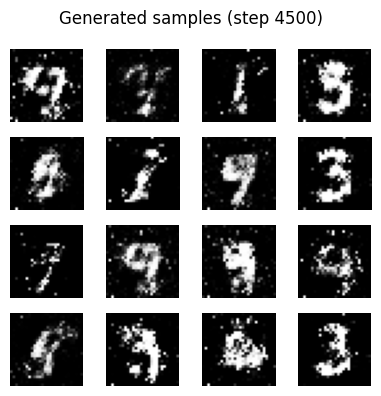

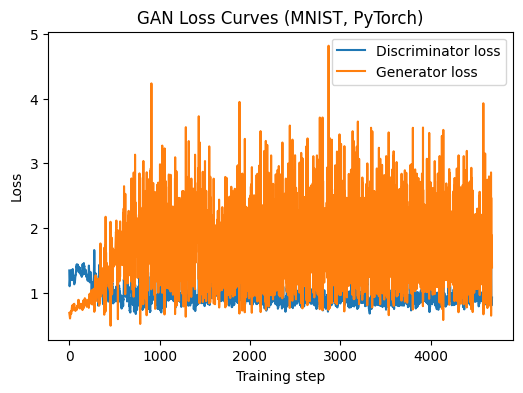

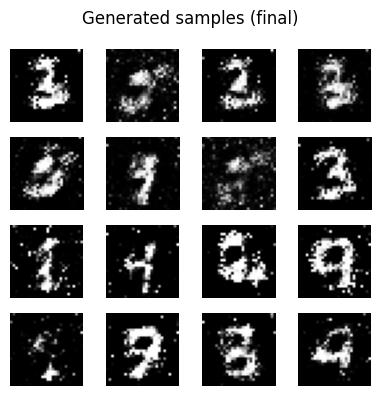

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MNIST dataloader (normalized to [-1, 1] for Tanh)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g, losses_d = [], []

def show_samples(step_label):
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, z_dim, device=device)
        fake = G(z).view(-1, 28, 28).cpu()
    G.train()

    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Generated samples ({step_label})")
    plt.tight_layout()
    plt.show()

# Train
num_epochs = 10   # set to 10 if you want better digits
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, torch.ones(bs, 1, device=device) * 0.9)


        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d.append(loss_D.item())
        losses_g.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"step {step}")

# Plot losses
plt.figure(figsize=(6, 4))
plt.plot(losses_d, label="Discriminator loss")
plt.plot(losses_g, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (MNIST, PyTorch)")
plt.legend()
plt.show()

show_samples("final")

### Observations on GAN training (MNIST)

After training a simple GAN on MNIST, the generator produced digit-like samples with visible stroke patterns. While the images are not perfectly clean and contain background noise, the outputs show recognizable handwritten-digit structure, indicating that the generator learned useful features of the MNIST distribution.

The GAN loss curves were highly unstable compared to logistic regression. The discriminator and generator losses fluctuated throughout training, reflecting the adversarial nature of GAN optimization. This instability is expected because the generator and discriminator continuously adapt to each other rather than converging smoothly to a single optimum.


## Comparison and Reflection

The discriminative **logistic regression** model performed strongly on MNIST, achieving a test accuracy of about **92% (best C=0.1)** using flattened 28×28 pixel inputs scaled to **[0,1]**. Its training behavior is straightforward and stable: the model optimizes a single objective, converges reliably, and evaluation is clear using accuracy, precision/recall, and a confusion matrix. Most classification errors occurred between visually similar digits (such as 4 vs 9 and 8 vs 5/3), which is expected for a linear classifier.

In contrast, the **GAN** is a generative model trained through an adversarial process between a generator and a discriminator. Unlike logistic regression, GAN training does not converge smoothly to a single optimum; instead, both networks continuously adapt to each other. This was reflected in the loss curves, where both discriminator and generator losses fluctuated significantly across training steps. Despite this instability, the generator eventually produced **digit-like samples** with recognizable stroke patterns, showing that it learned aspects of the MNIST distribution, although the outputs still contained noise and imperfect structure.

From a performance standpoint, logistic regression excels at classification tasks where outputs are easy to verify quantitatively. GANs are fundamentally different: they aim to generate realistic and diverse samples, so evaluation depends on visual quality, diversity, and training stability rather than accuracy. This experiment demonstrates that generative modeling is inherently harder because it requires learning a high-dimensional data distribution and maintaining balance in a competitive training game.

These differences inform real-world model selection. Logistic regression is best when the goal is **prediction and decision-making** (e.g., digit recognition, fraud detection, or medical classification). GANs are more suitable for **data generation tasks** (e.g., synthetic image creation, data augmentation, and creative applications), but they require more computational effort and careful tuning to produce high-quality results.



## Conclusion

This assignment demonstrated the key differences between discriminative and generative models using the MNIST dataset. Logistic regression provided a stable and efficient approach for classification, achieving strong accuracy with clear evaluation metrics and predictable training behavior. In contrast, the GAN highlighted the challenges of generative modeling, where training is less stable and output quality must be judged visually rather than through accuracy alone. Overall, the results show that discriminative models are more reliable for prediction tasks, while generative models are valuable for creating new data but require more careful tuning and computational effort to achieve realistic outputs.



# Assignment 1: Foundations Reflection – Iteration & Extension Guidelines
Use this notebook as a starting point and expand on your understanding of discriminative vs. generative models by completing the following structured tasks. You are encouraged to experiment, analyze, and critically reflect on your findings in your report.



## Part 1 – Discriminative Model (Logistic Regression) Extensions

### Step 1: Train a Non-linear Classifier for Comparison (Decision Tree)



In [7]:
# Step 1 Code: Non-linear classifier (Decision Tree)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train_lr, y_train_lr)

dt_pred = dt.predict(X_test_lr)
dt_acc = accuracy_score(y_test_lr, dt_pred)

print("Decision Tree test accuracy:", dt_acc)
print("\nDecision Tree classification report:\n", classification_report(y_test_lr, dt_pred))


Decision Tree test accuracy: 0.8768571428571429

Decision Tree classification report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92      1381
           1       0.95      0.96      0.95      1575
           2       0.87      0.85      0.86      1398
           3       0.85      0.85      0.85      1428
           4       0.86      0.88      0.87      1365
           5       0.82      0.83      0.82      1263
           6       0.92      0.89      0.90      1375
           7       0.90      0.92      0.91      1459
           8       0.84      0.80      0.82      1365
           9       0.83      0.84      0.84      1391

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000




To compare logistic regression (linear) with a non-linear classifier, I trained a Decision Tree on the same MNIST features. Decision Trees can learn non-linear decision boundaries by splitting the feature space, which helps illustrate how model complexity changes performance and generalization.


### Step 2: Experiment with Regularization (L1 vs L2)



In [8]:
# Step 2 Code: L2 vs L1 regularization
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# L2 (default)
lr_l2 = LogisticRegression(max_iter=3000, C=0.1, penalty="l2", solver="lbfgs")
lr_l2.fit(X_train_lr, y_train_lr)
pred_l2 = lr_l2.predict(X_test_lr)
acc_l2 = accuracy_score(y_test_lr, pred_l2)

# L1 (requires saga solver)
lr_l1 = LogisticRegression(max_iter=3000, C=0.1, penalty="l1", solver="saga")
lr_l1.fit(X_train_lr, y_train_lr)
pred_l1 = lr_l1.predict(X_test_lr)
acc_l1 = accuracy_score(y_test_lr, pred_l1)

print(f"L2 Logistic Regression (C=0.1) accuracy: {acc_l2:.4f}")
print(f"L1 Logistic Regression (C=0.1) accuracy: {acc_l1:.4f}")



L2 Logistic Regression (C=0.1) accuracy: 0.9215
L1 Logistic Regression (C=0.1) accuracy: 0.9170




I compared L2 and L1 regularization in logistic regression. L2 discourages large weights and tends to produce smoother weight patterns. L1 encourages sparsity by pushing many weights to zero, which can act like feature selection. This experiment shows how regularization type affects generalization and performance.


### Step 3: Feature Importance Visualization (Weight Maps)



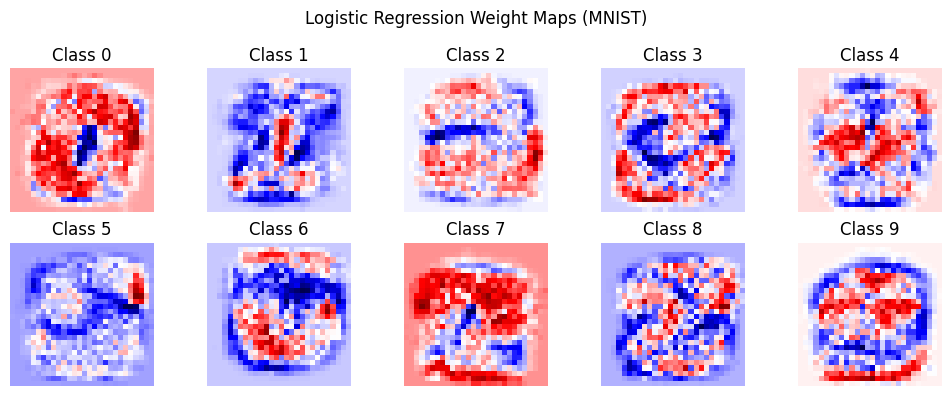

In [9]:
# Step 3 Code: Visualize logistic regression weights as 28x28 maps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

lr_vis = LogisticRegression(max_iter=3000, C=0.1, solver="lbfgs")
lr_vis.fit(X_train_lr, y_train_lr)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(lr_vis.coef_[i].reshape(28, 28), cmap="seismic")
    ax.set_title(f"Class {i}")
    ax.axis("off")

plt.suptitle("Logistic Regression Weight Maps (MNIST)")
plt.tight_layout()
plt.show()



To interpret what logistic regression learns, I visualized the learned weight vectors for each digit class as 28×28 heatmaps. Each heatmap shows which pixels most influence the model for that class. This helps reveal what the model focuses on for different digits.


### Step 4: Use Cross-Validation (5-Fold)

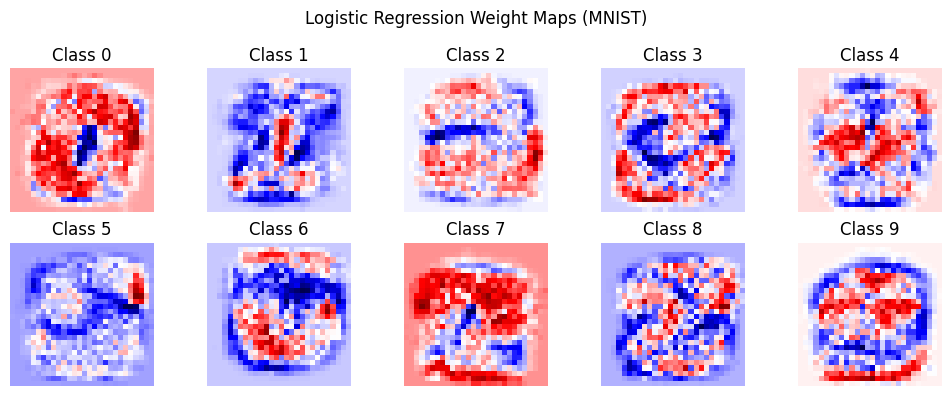

In [10]:
# Step 3 Code: Visualize logistic regression weights as 28x28 maps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

lr_vis = LogisticRegression(max_iter=3000, C=0.1, solver="lbfgs")
lr_vis.fit(X_train_lr, y_train_lr)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(lr_vis.coef_[i].reshape(28, 28), cmap="seismic")
    ax.set_title(f"Class {i}")
    ax.axis("off")

plt.suptitle("Logistic Regression Weight Maps (MNIST)")
plt.tight_layout()
plt.show()



To evaluate robustness beyond a single train/test split, I used 5-fold stratified cross-validation across the full MNIST dataset. The mean accuracy provides a more reliable estimate of model performance, and the standard deviation shows how stable the model is across different folds.


## Part 2 – Generative Model (GAN) Extensions




## Part 3 – Comparative Analysis & Meta Reflection



## Part 4 – Reporting Expectations



## 🌟 Bonus (Optional Advanced Ideas)


